# Topic #5. Numerical Algorithms and Scientific Computing, the SciPy Library

SciPy's Place in the Ecosystem: NumPy (Data Structures) vs. SciPy (Algorithms).

Philosophy: SciPy is a tool that enjoys widespread acceptance in the academic community (as opposed to MATLAB and R).

## The SciPy Library

[SciPy Main Website](https://scipy.org/)

[User Guide](https://docs.scipy.org/doc/scipy/tutorial/index.html)

[Installation Guide](https://scipy.org/install/)

[Source Code on GitHub](https://github.com/scipy/scipy)

### Optimization

The `scipy.optimize` module includes methods for both unconstrained and constrained optimization, as well as tools for curve fitting and solving linear programming problems.

Most methods are based on the minimize function, which provides a unified interface to various algorithms.

#### Basics of scipy.optimize.minimize

The main function for minimizing a scalar function of one or more variables is scipy.optimize.minimize. Its key parameters are:

- `fun`: The objective function to be minimized. It must accept a numpy array (`x`) and return a scalar value.

- `x0`: The initial condition (numpy array) from which the search begins.

- `method`: A string defining the optimization algorithm (e.g., `'Nelder-Mead'`, `'BFGS'`, `'Powell'`).

- `args`: A tuple of additional fixed arguments passed to the objective function `fun(x, *args)`.

- `jac`: A function that calculates the gradient (derivative) of the objective function. If omitted, the gradient is evaluated numerically.

- `bounds`: A sequence of ($\min$, $\max$) pairs defining the bounds for each variable.

- `constraints`: A list or dictionary describing constraints (equalities or inequalities).

#### Example 1: Unconstrained Minimization

Let's start with a classic problem—minimizing the Rosenbrock function. Its global minimum is at the point $(1, 1, ..., 1)$, where the function value is $0$.

##### Nelder-Mead Method

The Nelder-Mead method is a simplex method that does not require derivative calculations and is suitable for simple problems.

In [1]:
import numpy as np
from scipy.optimize import minimize

# Define the Rosenbrock function for N variables
def rosen(x):
    return sum(100.0 * (x[1:] - x[:-1]**2.0)**2.0 + (1 - x[:-1])**2.0)

# Initial approximation
x0 = np.array([1.3, 0.7, 0.8, 1.9, 1.2])

# Run minimization using the Nelder-Mead method
res = minimize(rosen, x0, method='Nelder-Mead',
               options={'xatol': 1e-8, 'disp': True})

print("Optimal solution (Nelder-Mead):", res.x)
print("Function value at minimum:", res.fun)

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 339
         Function evaluations: 571
Optimal solution (Nelder-Mead): [1. 1. 1. 1. 1.]
Function value at minimum: 4.861153433422115e-17


#### BFGS Method (Broyden-Fletcher-Goldfarb-Shanno Method)

The BFGS method is a more advanced gradient-based method. For its efficient operation, it is advisable to pass a function that calculates the gradient.

In [2]:
# Function for calculating the gradient of the Rosenbrock function
def rosen_der(x):
    xm = x[1:-1]
    xm_m1 = x[:-2]
    xm_p1 = x[2:]
    der = np.zeros_like(x)
    der[1:-1] = 200*(xm - xm_m1**2) - 400*(xm_p1 - xm**2)*xm - 2*(1 - xm)
    der[0] = -400*x[0]*(x[1] - x[0]**2) - 2*(1 - x[0])
    der[-1] = 200*(x[-1] - x[-2]**2)
    return der

# Run the minimization using the BFGS method, passing the gradient
res = minimize(rosen, x0, method='BFGS', jac=rosen_der,
               options={'disp': True})

print("Optimal solution (BFGS):", res.x)
print("Function value at minimum:", res.fun)

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 25
         Function evaluations: 30
         Gradient evaluations: 30
Optimal solution (BFGS): [1.00000004 1.0000001  1.00000021 1.00000044 1.00000092]
Function value at minimum: 4.0130879949972905e-13


BFGS, как правило, требует значительно меньше итераций, чем Nelder-Mead.

#### Example 2: Constrained Optimization

##### Example 0: The Simplest Example

Let's look at the simplest examples of unconstrained optimization.

**Minimize:**

$$
c^T x = 5x_1 + 4x_2 + 8x_3
$$

**Subject to constraints:**

$$
x_1 + x_2 + x_3 = 1,\quad x \ge 0
$$

In [3]:
from scipy.optimize import linprog

c = [5, 4, 8]

A_eq = [[1, 1, 1]]
b_eq = [1]

bounds = [(0, None), (0, None), (0, None)]

res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

print("Optimal solution:", res.x)
print("Minimum function value:", res.fun)

Optimal solution: [0. 1. 0.]
Minimum function value: 4.0


Now let's consider another problem with constraints. Suppose we need to minimize the cost of a cylindrical can whose volume must be exactly $355\ \text{cm}^3$.

**Objective Function (Cost):** $\text{cost}(D, L)$, where $D$ is the diameter and L is the length.

**Constraint (Equality):** $V = (\pi/4) D^2 L = 355$.

First, let's define the objective function and constraint function.

In [4]:
import numpy as np
from scipy.optimize import minimize

V = 355  # volume in cm^3
cost_top = 0.025  # cost of lid/bottom per cm^2
cost_side = 0.043  # cost of lateral surface area per cm^2

# Objective function: cost of the can
def objective(x):
    D, L = x
    radius = D / 2
    top_area = np.pi * radius**2
    side_area = L * np.pi * D
    return (2 * top_area * cost_top) + (side_area * cost_side)

# Constraint function
def constraint_volume(x):
    D, L = x
    radius = D / 2
    volume = np.pi * radius**2 * L
    return volume - V  # Return the difference, which should be 0

# Set the constraint as a dictionary
constraint = {'type': 'eq', 'fun': constraint_volume}

# Initial approximation
x0 = [9.2, 5.3]  # Diameter and length

# Solving a constrained optimization problem
res = minimize(objective, x0, constraints=constraint)

print("\nConditional optimization result:")
print("Optimal diameter (D):", res.x[0])
print("Optimal length (L):", res.x[1])
print("Minimum cost (fun):", res.fun)


Conditional optimization result:
Optimal diameter (D): 9.195083068889426
Optimal length (L): 5.3459778819088655
Minimum cost (fun): 9.960758701305975


For problems with constraints, there are also special classes `LinearConstraint` and `NonlinearConstraint`.

#### Example 3: Curve Fitting

`scipy.optimize` provides the `curve_fit` function for fitting model parameters to experimental data. This is a special case of least-squares optimization.


Результат подбора кривой:
True parameters: omega=1.5, phi=1.0
Found parameters: omega=1.487, phi=1.010


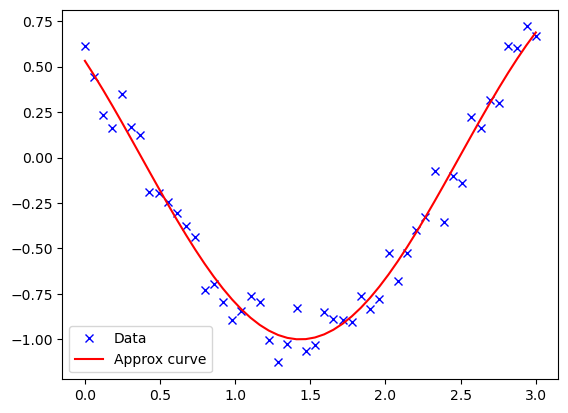

In [5]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Model function: cosine with unknown frequency and phase
def model_func(t, omega, phi):
    return np.cos(omega * t + phi)

# Generate "experimental" data with noise
xdata = np.linspace(0, 3, 50)
true_params = [1.5, 1.0]
ydata = model_func(xdata, *true_params) + 0.1 * np.random.normal(size=len(xdata))

# Fitting the model to the data
popt, pcov = curve_fit(model_func, xdata, ydata, p0=[1, 1])

# `popt` contains optimal parameter values
print("\nРезультат подбора кривой:")
print(f"True parameters: omega={true_params[0]}, phi={true_params[1]}")
print(f"Found parameters: omega={popt[0]:.3f}, phi={popt[1]:.3f}")

# Visualization of the result
plt.plot(xdata, ydata, 'bx', label='Data')
plt.plot(xdata, model_func(xdata, *popt), 'r-', label='Approx curve')
plt.legend()
plt.show()

### Practical Part

#### Problem 1

Write a program that solves the following constrained optimization problem.

**Minimize:**

$$
c^T x = 5x_1 + 4x_2 + 8x_3
$$

**Subject to constraints:**

$$
x_1 + x_2 + x_3 \le 1,\quad x \ge 0
$$

#### Problem 2

Problem: Given experimental points $(x, y)$ with noise (you need to prepare the input parameters yourself, take a function, for example, a trigonometric function, and add noise to it).

- Use `curve_fit` to fit a model of the form $y=a⋅\exp⁡(−b⋅x)+cy=a⋅\exp(−b⋅x)+c$.

The methods for solving the following two points were not discussed in this summary, but you can figure them out on your own:

- Calculate the area under the resulting curve (the integral from $0$ to $\max$).

- Using `solve_ivp`, construct a phase portrait for the fitted model (if it is a differential equation).